📂 Loaded: sam_segmentation_results/segmentation_data_ThuaDong_20250618_163100.json
🎯 Class: ThuaDong
🔄 Theta: -89.61°
📊 Contour Points: 84


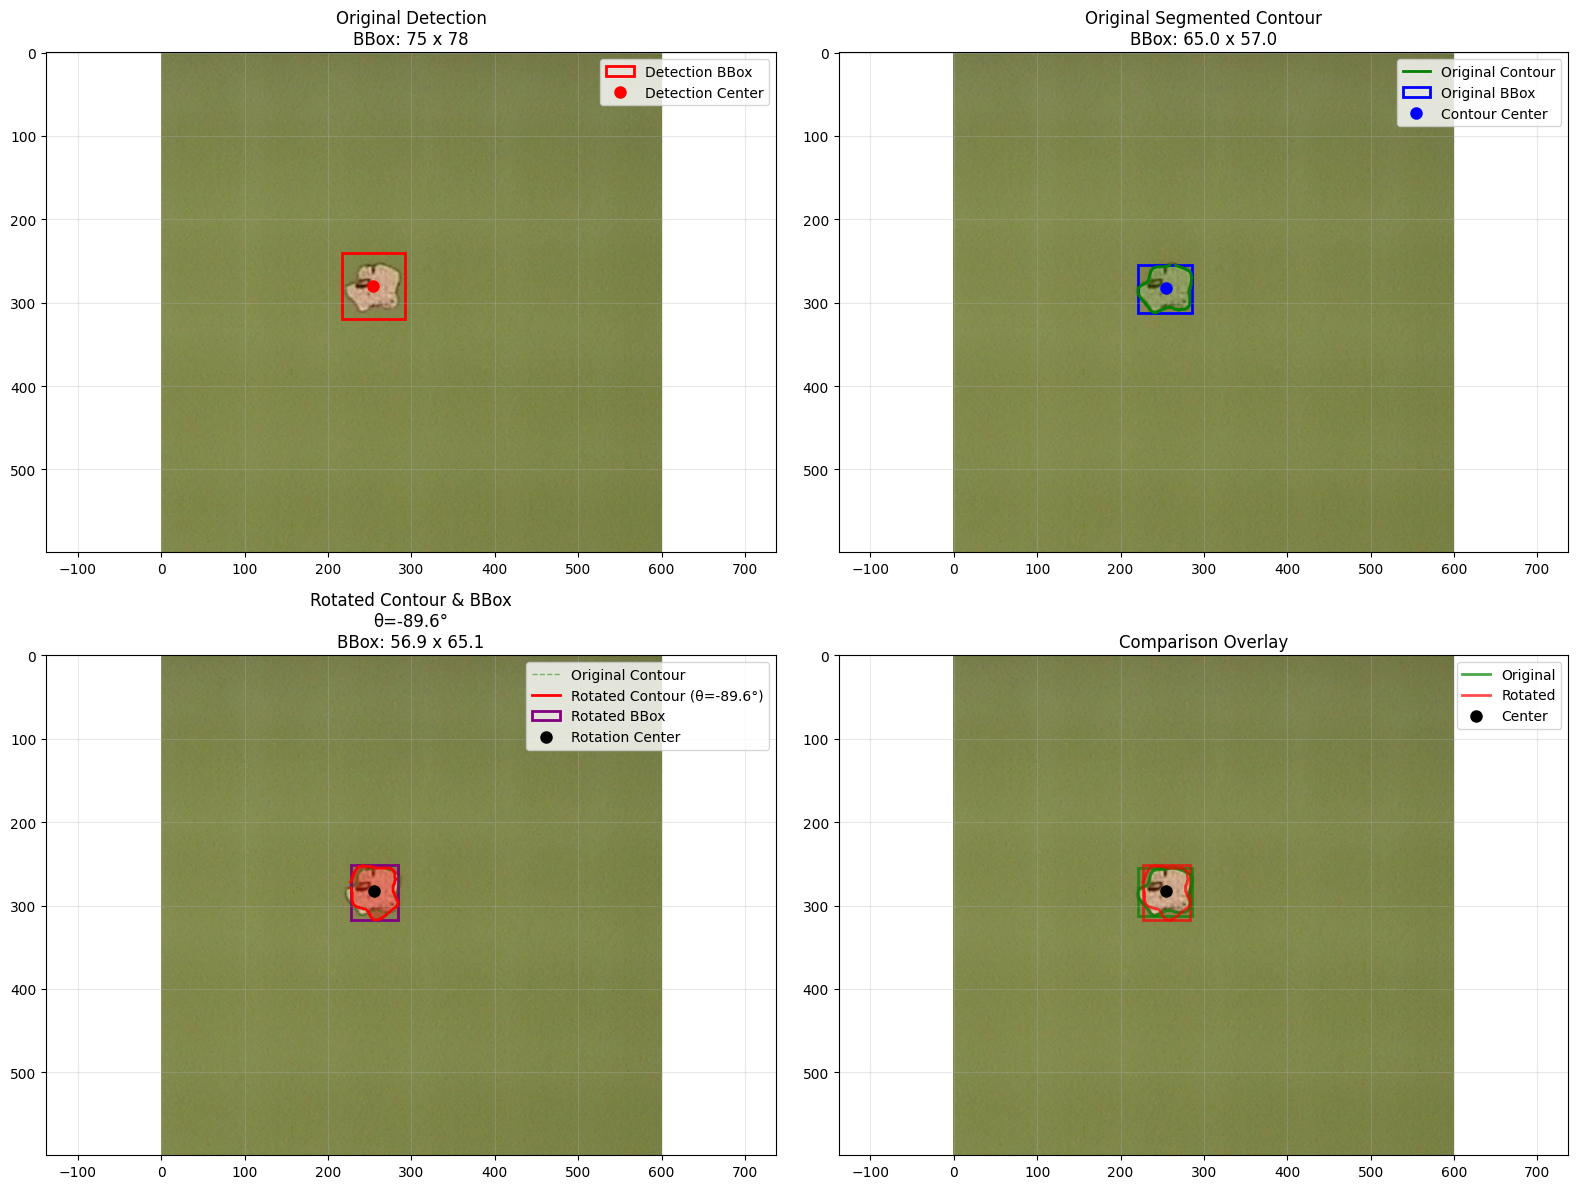


🎯 ROTATED CONTOUR ANALYSIS:
   📐 Rotation Angle: -89.61°
   📍 Rotation Center: (255.0, 283.0)

📏 ORIGINAL CONTOUR:
   BBox: 65.0 x 57.0 px
   Area: 3705.0 px²
   Center: (253.5, 283.5)

📏 ROTATED CONTOUR:
   BBox: 56.9 x 65.1 px
   Area: 3705.1 px²
   Center: (255.5, 284.5)

📊 COMPARISON:
   Width Change: -8.1 px
   Height Change: 8.1 px
   Area Change: 0.1 px²

💾 Visualization: rotated_contour_analysis_20250618_163100.png
❌ Error: Object of type int64 is not JSON serializable


Traceback (most recent call last):
  File "/tmp/ipykernel_50378/921571109.py", line 234, in main
    save_rotated_contour_data(rotation_data, seg_data)
  File "/tmp/ipykernel_50378/921571109.py", line 211, in save_rotated_contour_data
    json.dump(output_data, f, indent=2)
  File "/home/jkl0909/miniconda3/envs/ts_yolo12/lib/python3.10/json/__init__.py", line 179, in dump
    for chunk in iterable:
  File "/home/jkl0909/miniconda3/envs/ts_yolo12/lib/python3.10/json/encoder.py", line 431, in _iterencode
    yield from _iterencode_dict(o, _current_indent_level)
  File "/home/jkl0909/miniconda3/envs/ts_yolo12/lib/python3.10/json/encoder.py", line 405, in _iterencode_dict
    yield from chunks
  File "/home/jkl0909/miniconda3/envs/ts_yolo12/lib/python3.10/json/encoder.py", line 405, in _iterencode_dict
    yield from chunks
  File "/home/jkl0909/miniconda3/envs/ts_yolo12/lib/python3.10/json/encoder.py", line 405, in _iterencode_dict
    yield from chunks
  File "/home/jkl0909/miniconda3/en

In [3]:
#!/usr/bin/env python3
"""
Rotate Segmented Contour and Calculate Rotated Bounding Box
"""

import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple

def load_segmentation_json(json_file: str) -> dict:
    """Load segmentation JSON data"""
    with open(json_file, 'r') as f:
        return json.load(f)

def rotate_contour(points: List[List[int]], center: Tuple[float, float], theta: float) -> np.ndarray:
    """Rotate entire contour around center by theta degrees"""
    
    # Convert to numpy array
    points_array = np.array(points, dtype=float)
    
    # Convert angle to radians
    angle_rad = np.radians(theta)
    cos_theta = np.cos(angle_rad)
    sin_theta = np.sin(angle_rad)
    
    # Translate to origin (center)
    translated_points = points_array - np.array(center)
    
    # Apply rotation matrix
    rotation_matrix = np.array([
        [cos_theta, -sin_theta],
        [sin_theta, cos_theta]
    ])
    
    rotated_points = translated_points @ rotation_matrix.T
    
    # Translate back
    final_points = rotated_points + np.array(center)
    
    return final_points

def calculate_bounding_box(points: np.ndarray) -> dict:
    """Calculate bounding box from points"""
    
    x_min, y_min = np.min(points, axis=0)
    x_max, y_max = np.max(points, axis=0)
    
    width = x_max - x_min
    height = y_max - y_min
    center = [(x_min + x_max) / 2, (y_min + y_max) / 2]
    
    return {
        "x_min": x_min, "y_min": y_min,
        "x_max": x_max, "y_max": y_max,
        "width": width, "height": height,
        "center": center,
        "area": width * height
    }

def visualize_rotated_contour(image_path: str, seg_data: dict):
    """Visualize rotated contour and its bounding box"""
    
    # Load image
    image = cv2.imread(image_path)
    if image is None:
        print(f"❌ Cannot load image: {image_path}")
        return
    
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Get data
    theta = seg_data["theta"]
    contour = seg_data["contours"][0]
    points = contour["points"]
    original_center = [contour["center"]["x"], contour["center"]["y"]]
    
    # Rotate the entire contour
    rotated_contour = rotate_contour(points, original_center, theta)
    
    # Calculate bounding boxes
    original_bbox = calculate_bounding_box(np.array(points))
    rotated_bbox = calculate_bounding_box(rotated_contour)
    
    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Original detection
    axes[0, 0].imshow(image_rgb)
    coords = seg_data["coordinates"]
    detection_rect = plt.Rectangle((coords["x1"], coords["y1"]), 
                                  coords["x2"] - coords["x1"], 
                                  coords["y2"] - coords["y1"], 
                                  fill=False, color='red', linewidth=2, label='Detection BBox')
    axes[0, 0].add_patch(detection_rect)
    axes[0, 0].plot(seg_data["center"]["x"], seg_data["center"]["y"], 'ro', markersize=8, label='Detection Center')
    axes[0, 0].set_title(f"Original Detection\nBBox: {coords['x2']-coords['x1']} x {coords['y2']-coords['y1']}")
    axes[0, 0].legend()
    axes[0, 0].axis('equal')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Original segmented contour
    axes[0, 1].imshow(image_rgb)
    original_points = np.array(points)
    axes[0, 1].plot(original_points[:, 0], original_points[:, 1], 'g-', linewidth=2, label='Original Contour')
    axes[0, 1].fill(original_points[:, 0], original_points[:, 1], 'green', alpha=0.3)
    
    # Original contour bounding box
    orig_rect = plt.Rectangle((original_bbox["x_min"], original_bbox["y_min"]), 
                             original_bbox["width"], original_bbox["height"],
                             fill=False, color='blue', linewidth=2, label='Original BBox')
    axes[0, 1].add_patch(orig_rect)
    axes[0, 1].plot(original_center[0], original_center[1], 'bo', markersize=8, label='Contour Center')
    axes[0, 1].set_title(f"Original Segmented Contour\nBBox: {original_bbox['width']:.1f} x {original_bbox['height']:.1f}")
    axes[0, 1].legend()
    axes[0, 1].axis('equal')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Rotated contour
    axes[1, 0].imshow(image_rgb)
    # Draw original contour (faded)
    axes[1, 0].plot(original_points[:, 0], original_points[:, 1], 'g--', linewidth=1, alpha=0.5, label='Original Contour')
    
    # Draw rotated contour
    axes[1, 0].plot(rotated_contour[:, 0], rotated_contour[:, 1], 'r-', linewidth=2, label=f'Rotated Contour (θ={theta:.1f}°)')
    axes[1, 0].fill(rotated_contour[:, 0], rotated_contour[:, 1], 'red', alpha=0.3)
    
    # Rotated contour bounding box
    rot_rect = plt.Rectangle((rotated_bbox["x_min"], rotated_bbox["y_min"]), 
                            rotated_bbox["width"], rotated_bbox["height"],
                            fill=False, color='purple', linewidth=2, label='Rotated BBox')
    axes[1, 0].add_patch(rot_rect)
    axes[1, 0].plot(original_center[0], original_center[1], 'ko', markersize=8, label='Rotation Center')
    axes[1, 0].set_title(f"Rotated Contour & BBox\nθ={theta:.1f}°\nBBox: {rotated_bbox['width']:.1f} x {rotated_bbox['height']:.1f}")
    axes[1, 0].legend()
    axes[1, 0].axis('equal')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Comparison overlay
    axes[1, 1].imshow(image_rgb)
    # Original
    axes[1, 1].plot(original_points[:, 0], original_points[:, 1], 'g-', linewidth=2, alpha=0.7, label='Original')
    axes[1, 1].add_patch(plt.Rectangle((original_bbox["x_min"], original_bbox["y_min"]), 
                                      original_bbox["width"], original_bbox["height"],
                                      fill=False, color='green', linewidth=2, alpha=0.7))
    
    # Rotated
    axes[1, 1].plot(rotated_contour[:, 0], rotated_contour[:, 1], 'r-', linewidth=2, alpha=0.7, label='Rotated')
    axes[1, 1].add_patch(plt.Rectangle((rotated_bbox["x_min"], rotated_bbox["y_min"]), 
                                      rotated_bbox["width"], rotated_bbox["height"],
                                      fill=False, color='red', linewidth=2, alpha=0.7))
    
    axes[1, 1].plot(original_center[0], original_center[1], 'ko', markersize=8, label='Center')
    axes[1, 1].set_title("Comparison Overlay")
    axes[1, 1].legend()
    axes[1, 1].axis('equal')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save result
    output_file = f"rotated_contour_analysis_{seg_data['timestamp']}.png"
    plt.savefig(output_file, dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print detailed results
    print(f"\n🎯 ROTATED CONTOUR ANALYSIS:")
    print(f"   📐 Rotation Angle: {theta:.2f}°")
    print(f"   📍 Rotation Center: ({original_center[0]:.1f}, {original_center[1]:.1f})")
    
    print(f"\n📏 ORIGINAL CONTOUR:")
    print(f"   BBox: {original_bbox['width']:.1f} x {original_bbox['height']:.1f} px")
    print(f"   Area: {original_bbox['area']:.1f} px²")
    print(f"   Center: ({original_bbox['center'][0]:.1f}, {original_bbox['center'][1]:.1f})")
    
    print(f"\n📏 ROTATED CONTOUR:")
    print(f"   BBox: {rotated_bbox['width']:.1f} x {rotated_bbox['height']:.1f} px") 
    print(f"   Area: {rotated_bbox['area']:.1f} px²")
    print(f"   Center: ({rotated_bbox['center'][0]:.1f}, {rotated_bbox['center'][1]:.1f})")
    
    print(f"\n📊 COMPARISON:")
    print(f"   Width Change: {rotated_bbox['width'] - original_bbox['width']:.1f} px")
    print(f"   Height Change: {rotated_bbox['height'] - original_bbox['height']:.1f} px")
    print(f"   Area Change: {rotated_bbox['area'] - original_bbox['area']:.1f} px²")
    
    print(f"\n💾 Visualization: {output_file}")
    
    return {
        "original_contour": points,
        "rotated_contour": rotated_contour.tolist(),
        "original_bbox": original_bbox,
        "rotated_bbox": rotated_bbox,
        "rotation_center": original_center,
        "theta": theta
    }

def save_rotated_contour_data(rotation_data: dict, seg_data: dict):
    """Save rotated contour data to JSON"""
    
    output_data = {
        "original_segmentation": seg_data,
        "rotation_analysis": rotation_data,
        "timestamp": seg_data["timestamp"],
        "rotation_applied": True
    }
    
    output_file = f"rotated_contour_data_{seg_data['timestamp']}.json"
    
    with open(output_file, 'w') as f:
        json.dump(output_data, f, indent=2)
    
    print(f"📋 Rotated contour data saved: {output_file}")
    return output_file

def main():
    """Main function"""
    
    # Load JSON data
    json_file = "sam_segmentation_results/segmentation_data_ThuaDong_20250618_163100.json"
    image_path = "/home/jkl0909/TestCycletimeMeiko/PCB_Project/data/raw/thuadong/testthuadong.jpg"
    
    try:
        seg_data = load_segmentation_json(json_file)
        print(f"📂 Loaded: {json_file}")
        print(f"🎯 Class: {seg_data['class_name']}")
        print(f"🔄 Theta: {seg_data['theta']:.2f}°")
        print(f"📊 Contour Points: {len(seg_data['contours'][0]['points'])}")
        
        # Rotate and visualize contour
        rotation_data = visualize_rotated_contour(image_path, seg_data)
        
        # Save rotated data
        save_rotated_contour_data(rotation_data, seg_data)
        
    except Exception as e:
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

📂 Loaded: sam_segmentation_results/segmentation_data_ThuaDong_20250618_163100.json
🎯 Class: ThuaDong
🔄 Theta: 45.00°
📊 Contour Points: 84


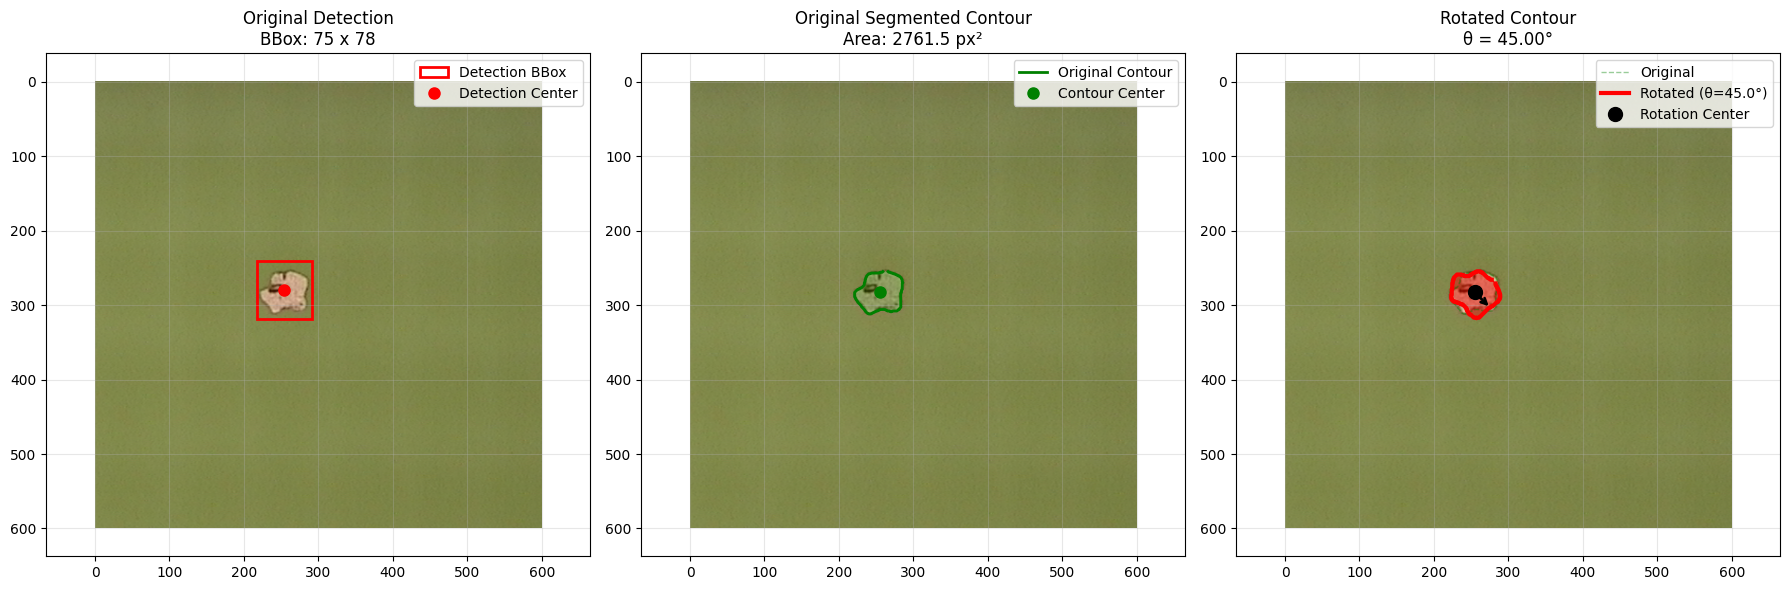


🎯 ROTATED CONTOUR ANALYSIS:
   📐 Rotation Angle: 45.00°
   📍 Rotation Center: (255.0, 283.0)
   📊 Original Area: 2761.5 px²
   📊 Points Count: 84
   💾 Visualization: rotated_contour_only_20250618_163100.png
📋 Rotated contour data saved: rotated_contour_data_20250618_163100.json


In [7]:
#!/usr/bin/env python3
"""
Rotate Segmented Contour (No Bounding Box)
"""

import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple

def load_segmentation_json(json_file: str) -> dict:
    """Load segmentation JSON data"""
    with open(json_file, 'r') as f:
        return json.load(f)

def rotate_contour(points: List[List[int]], center: Tuple[float, float], theta: float) -> np.ndarray:
    """Rotate entire contour around center by theta degrees"""
    
    # Convert to numpy array
    points_array = np.array(points, dtype=float)
    
    # Convert angle to radians
    angle_rad = np.radians(theta)
    cos_theta = np.cos(angle_rad)
    sin_theta = np.sin(angle_rad)
    
    # Translate to origin (center)
    translated_points = points_array - np.array(center)
    
    # Apply rotation matrix
    rotation_matrix = np.array([
        [cos_theta, -sin_theta],
        [sin_theta, cos_theta]
    ])
    
    rotated_points = translated_points @ rotation_matrix.T
    
    # Translate back
    final_points = rotated_points + np.array(center)
    
    return final_points

def visualize_rotated_contour(image_path: str, seg_data: dict):
    """Visualize rotated contour only"""
    
    # Load image
    image = cv2.imread(image_path)
    if image is None:
        print(f"❌ Cannot load image: {image_path}")
        return
    
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Get data
    theta = seg_data["theta"]
    contour = seg_data["contours"][0]
    points = contour["points"]
    original_center = [contour["center"]["x"], contour["center"]["y"]]
    
    # Rotate the entire contour
    rotated_contour = rotate_contour(points, original_center, theta)
    
    # Create visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # 1. Original detection
    axes[0].imshow(image_rgb)
    coords = seg_data["coordinates"]
    detection_rect = plt.Rectangle((coords["x1"], coords["y1"]), 
                                  coords["x2"] - coords["x1"], 
                                  coords["y2"] - coords["y1"], 
                                  fill=False, color='red', linewidth=2, label='Detection BBox')
    axes[0].add_patch(detection_rect)
    axes[0].plot(seg_data["center"]["x"], seg_data["center"]["y"], 'ro', markersize=8, label='Detection Center')
    axes[0].set_title(f"Original Detection\nBBox: {coords['x2']-coords['x1']} x {coords['y2']-coords['y1']}")
    axes[0].legend()
    axes[0].axis('equal')
    axes[0].grid(True, alpha=0.3)
    
    # 2. Original segmented contour
    axes[1].imshow(image_rgb)
    original_points = np.array(points)
    axes[1].plot(original_points[:, 0], original_points[:, 1], 'g-', linewidth=2, label='Original Contour')
    axes[1].fill(original_points[:, 0], original_points[:, 1], 'green', alpha=0.3)
    axes[1].plot(original_center[0], original_center[1], 'go', markersize=8, label='Contour Center')
    axes[1].set_title(f"Original Segmented Contour\nArea: {contour['area']:.1f} px²")
    axes[1].legend()
    axes[1].axis('equal')
    axes[1].grid(True, alpha=0.3)
    
    # 3. Rotated contour only
    axes[2].imshow(image_rgb)
    # Draw original contour (faded)
    axes[2].plot(original_points[:, 0], original_points[:, 1], 'g--', linewidth=1, alpha=0.4, label='Original')
    
    # Draw rotated contour
    axes[2].plot(rotated_contour[:, 0], rotated_contour[:, 1], 'r-', linewidth=3, label=f'Rotated (θ={theta:.1f}°)')
    axes[2].fill(rotated_contour[:, 0], rotated_contour[:, 1], 'red', alpha=0.4)
    
    # Show rotation center
    axes[2].plot(original_center[0], original_center[1], 'ko', markersize=10, label='Rotation Center')
    
    # Add rotation arrow
    arrow_length = 30
    arrow_end_x = original_center[0] + arrow_length * np.cos(np.radians(theta))
    arrow_end_y = original_center[1] + arrow_length * np.sin(np.radians(theta))
    axes[2].annotate('', xy=(arrow_end_x, arrow_end_y), xytext=original_center,
                    arrowprops=dict(arrowstyle='->', color='black', lw=2))
    
    axes[2].set_title(f"Rotated Contour\nθ = {theta:.2f}°")
    axes[2].legend()
    axes[2].axis('equal')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save result
    output_file = f"rotated_contour_only_{seg_data['timestamp']}.png"
    plt.savefig(output_file, dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print results
    print(f"\n🎯 ROTATED CONTOUR ANALYSIS:")
    print(f"   📐 Rotation Angle: {theta:.2f}°")
    print(f"   📍 Rotation Center: ({original_center[0]:.1f}, {original_center[1]:.1f})")
    print(f"   📊 Original Area: {contour['area']:.1f} px²")
    print(f"   📊 Points Count: {len(points)}")
    print(f"   💾 Visualization: {output_file}")
    
    return {
        "original_contour": points,
        "rotated_contour": rotated_contour.tolist(),
        "rotation_center": original_center,
        "theta": theta,
        "area": contour["area"]
    }

def save_rotated_contour_data(rotation_data: dict, seg_data: dict):
    """Save rotated contour data to JSON"""
    
    output_data = {
        "class_name": seg_data["class_name"],
        "timestamp": seg_data["timestamp"],
        "theta": rotation_data["theta"],
        "rotation_center": rotation_data["rotation_center"],
        "original_contour": rotation_data["original_contour"],
        "rotated_contour": rotation_data["rotated_contour"],
        "contour_area": rotation_data["area"],
        "points_count": len(rotation_data["original_contour"])
    }
    
    output_file = f"rotated_contour_data_{seg_data['timestamp']}.json"
    
    with open(output_file, 'w') as f:
        json.dump(output_data, f, indent=2)
    
    print(f"📋 Rotated contour data saved: {output_file}")
    return output_file

def main():
    """Main function"""
    
    # Load JSON data
    json_file = "sam_segmentation_results/segmentation_data_ThuaDong_20250618_163100.json"
    image_path = "/home/jkl0909/TestCycletimeMeiko/PCB_Project/data/raw/thuadong/testthuadong.jpg"
    
    try:
        seg_data = load_segmentation_json(json_file)
        print(f"📂 Loaded: {json_file}")
        print(f"🎯 Class: {seg_data['class_name']}")
        print(f"🔄 Theta: {seg_data['theta']:.2f}°")
        print(f"📊 Contour Points: {len(seg_data['contours'][0]['points'])}")
        
        # Rotate and visualize contour
        rotation_data = visualize_rotated_contour(image_path, seg_data)
        
        # Save rotated data
        save_rotated_contour_data(rotation_data, seg_data)
        
    except Exception as e:
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

📂 Loaded: /home/jkl0909/TestCycletimeMeiko/sam_segmentation_results/segmentation_data_Xuoc_20250618_170905.json
🎯 Class: Xuoc
🔄 Theta: -43.40°


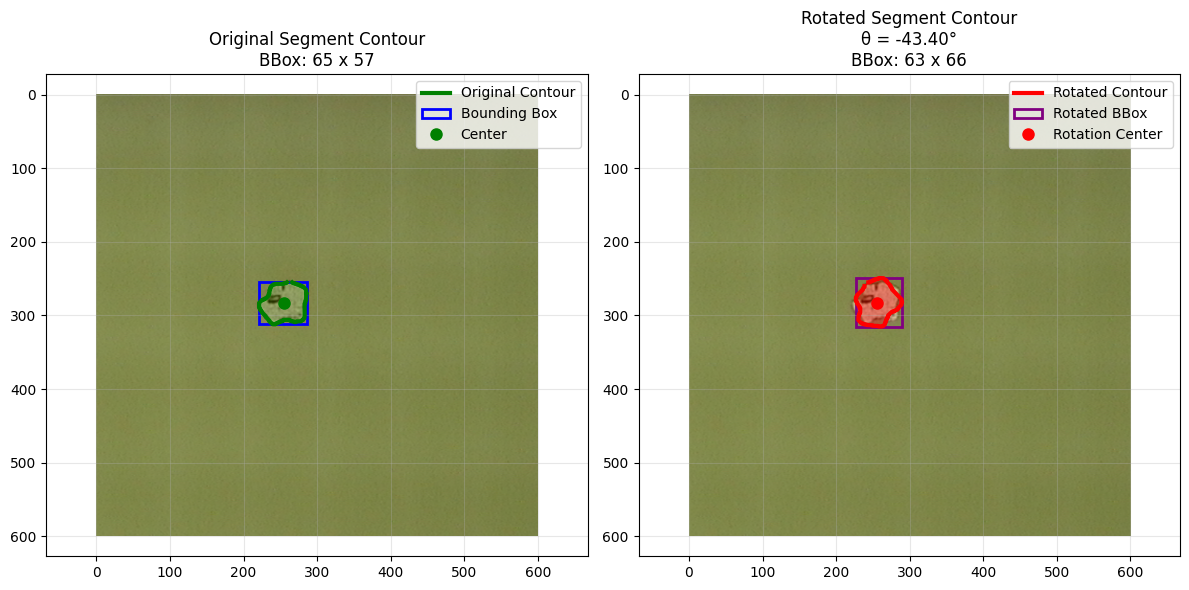


🎯 SEGMENT CONTOUR ANALYSIS:
   📐 Rotation Angle: -43.40°
   📍 Rotation Center: (255.0, 283.0)

📏 ORIGINAL CONTOUR BOUNDING BOX:
   x_min: 221.0
   x_max: 286.0
   y_min: 255.0
   y_max: 312.0
   Width: 65.0 px
   Height: 57.0 px

📏 ROTATED CONTOUR BOUNDING BOX:
   x_min: 226.8
   x_max: 289.7
   y_min: 249.2
   y_max: 315.0
   Width: 62.9 px
   Height: 65.9 px

📊 BOUNDING BOX COMPARISON:
   Width Change: -2.1 px
   Height Change: 8.9 px

💾 Visualization: segment_contours_with_bbox_20250618_170905.png
📋 Bounding box coordinates saved: rotated_bbox_coordinates_20250618_170905.json


In [9]:
#!/usr/bin/env python3
"""
Rotate Segmented Contour with Bounding Box
"""

import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple

def load_segmentation_json(json_file: str) -> dict:
    """Load segmentation JSON data"""
    with open(json_file, 'r') as f:
        return json.load(f)

def rotate_contour(points: List[List[int]], center: Tuple[float, float], theta: float) -> np.ndarray:
    """Rotate entire contour around center by theta degrees"""
    
    # Convert to numpy array
    points_array = np.array(points, dtype=float)
    
    # Convert angle to radians
    angle_rad = np.radians(theta)
    cos_theta = np.cos(angle_rad)
    sin_theta = np.sin(angle_rad)
    
    # Translate to origin (center)
    translated_points = points_array - np.array(center)
    
    # Apply rotation matrix
    rotation_matrix = np.array([
        [cos_theta, -sin_theta],
        [sin_theta, cos_theta]
    ])
    
    rotated_points = translated_points @ rotation_matrix.T
    
    # Translate back
    final_points = rotated_points + np.array(center)
    
    return final_points

def get_bounding_box_coordinates(points: np.ndarray) -> dict:
    """Get bounding box coordinates from points"""
    
    x_min = np.min(points[:, 0])
    x_max = np.max(points[:, 0])
    y_min = np.min(points[:, 1])
    y_max = np.max(points[:, 1])
    
    width = x_max - x_min
    height = y_max - y_min
    
    return {
        "x_min": float(x_min),
        "x_max": float(x_max),
        "y_min": float(y_min),
        "y_max": float(y_max),
        "width": float(width),
        "height": float(height)
    }

def visualize_contours_with_bbox(image_path: str, seg_data: dict):
    """Visualize original and rotated contours with bounding boxes"""
    
    # Load image
    image = cv2.imread(image_path)
    if image is None:
        print(f"❌ Cannot load image: {image_path}")
        return
    
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Get data
    theta = seg_data["theta"]
    contour = seg_data["contours"][0]
    points = contour["points"]
    original_center = [contour["center"]["x"], contour["center"]["y"]]
    
    # Convert original points to numpy array
    original_points = np.array(points)
    
    # Get original bounding box
    original_bbox = get_bounding_box_coordinates(original_points)
    
    # Rotate the entire contour
    rotated_contour = rotate_contour(points, original_center, theta)
    
    # Get rotated contour bounding box
    rotated_bbox = get_bounding_box_coordinates(rotated_contour)
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # 1. Original segmented contour with bounding box
    axes[0].imshow(image_rgb)
    axes[0].plot(original_points[:, 0], original_points[:, 1], 'g-', linewidth=3, label='Original Contour')
    axes[0].fill(original_points[:, 0], original_points[:, 1], 'green', alpha=0.3)
    
    # Draw original bounding box
    orig_rect = plt.Rectangle((original_bbox["x_min"], original_bbox["y_min"]), 
                             original_bbox["width"], original_bbox["height"],
                             fill=False, color='blue', linewidth=2, label='Bounding Box')
    axes[0].add_patch(orig_rect)
    
    axes[0].plot(original_center[0], original_center[1], 'go', markersize=8, label='Center')
    axes[0].set_title(f"Original Segment Contour\nBBox: {original_bbox['width']:.0f} x {original_bbox['height']:.0f}")
    axes[0].legend()
    axes[0].axis('equal')
    axes[0].grid(True, alpha=0.3)
    
    # 2. Rotated contour with bounding box
    axes[1].imshow(image_rgb)
    axes[1].plot(rotated_contour[:, 0], rotated_contour[:, 1], 'r-', linewidth=3, label=f'Rotated Contour')
    axes[1].fill(rotated_contour[:, 0], rotated_contour[:, 1], 'red', alpha=0.3)
    
    # Draw rotated contour bounding box
    rot_rect = plt.Rectangle((rotated_bbox["x_min"], rotated_bbox["y_min"]), 
                            rotated_bbox["width"], rotated_bbox["height"],
                            fill=False, color='purple', linewidth=2, label='Rotated BBox')
    axes[1].add_patch(rot_rect)
    
    axes[1].plot(original_center[0], original_center[1], 'ro', markersize=8, label='Rotation Center')
    axes[1].set_title(f"Rotated Segment Contour\nθ = {theta:.2f}°\nBBox: {rotated_bbox['width']:.0f} x {rotated_bbox['height']:.0f}")
    axes[1].legend()
    axes[1].axis('equal')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save result
    output_file = f"segment_contours_with_bbox_{seg_data['timestamp']}.png"
    plt.savefig(output_file, dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print detailed coordinates
    print(f"\n🎯 SEGMENT CONTOUR ANALYSIS:")
    print(f"   📐 Rotation Angle: {theta:.2f}°")
    print(f"   📍 Rotation Center: ({original_center[0]:.1f}, {original_center[1]:.1f})")
    
    print(f"\n📏 ORIGINAL CONTOUR BOUNDING BOX:")
    print(f"   x_min: {original_bbox['x_min']:.1f}")
    print(f"   x_max: {original_bbox['x_max']:.1f}")
    print(f"   y_min: {original_bbox['y_min']:.1f}")
    print(f"   y_max: {original_bbox['y_max']:.1f}")
    print(f"   Width: {original_bbox['width']:.1f} px")
    print(f"   Height: {original_bbox['height']:.1f} px")
    
    print(f"\n📏 ROTATED CONTOUR BOUNDING BOX:")
    print(f"   x_min: {rotated_bbox['x_min']:.1f}")
    print(f"   x_max: {rotated_bbox['x_max']:.1f}")
    print(f"   y_min: {rotated_bbox['y_min']:.1f}")
    print(f"   y_max: {rotated_bbox['y_max']:.1f}")
    print(f"   Width: {rotated_bbox['width']:.1f} px")
    print(f"   Height: {rotated_bbox['height']:.1f} px")
    
    print(f"\n📊 BOUNDING BOX COMPARISON:")
    print(f"   Width Change: {rotated_bbox['width'] - original_bbox['width']:.1f} px")
    print(f"   Height Change: {rotated_bbox['height'] - original_bbox['height']:.1f} px")
    
    print(f"\n💾 Visualization: {output_file}")
    
    return {
        "original_contour": points,
        "rotated_contour": rotated_contour.tolist(),
        "original_bbox": original_bbox,
        "rotated_bbox": rotated_bbox,
        "rotation_center": original_center,
        "theta": theta
    }

def save_bbox_coordinates(bbox_data: dict, seg_data: dict):
    """Save bounding box coordinates to file"""
    
    output_data = {
        "class_name": seg_data["class_name"],
        "timestamp": seg_data["timestamp"],
        "theta": bbox_data["theta"],
        "rotation_center": bbox_data["rotation_center"],
        "original_bbox": bbox_data["original_bbox"],
        "rotated_bbox": bbox_data["rotated_bbox"],
        "rotated_contour_points": bbox_data["rotated_contour"]
    }
    
    output_file = f"rotated_bbox_coordinates_{seg_data['timestamp']}.json"
    
    with open(output_file, 'w') as f:
        json.dump(output_data, f, indent=2)
    
    print(f"📋 Bounding box coordinates saved: {output_file}")
    return output_file

def main():
    """Main function"""
    
    # Load JSON data
    json_file = "/home/jkl0909/TestCycletimeMeiko/sam_segmentation_results/segmentation_data_Xuoc_20250618_170905.json"
    image_path = "/home/jkl0909/TestCycletimeMeiko/PCB_Project/data/raw/thuadong/testthuadong.jpg"
    
    try:
        seg_data = load_segmentation_json(json_file)
        print(f"📂 Loaded: {json_file}")
        print(f"🎯 Class: {seg_data['class_name']}")
        print(f"🔄 Theta: {seg_data['theta']:.2f}°")
        
        # Visualize contours with bounding boxes
        bbox_data = visualize_contours_with_bbox(image_path, seg_data)
        
        # Save coordinates
        save_bbox_coordinates(bbox_data, seg_data)
        
    except Exception as e:
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


📂 Loaded: sam_segmentation_results/segmentation_data_ThuaDong_20250618_163100.json
🎯 Class: ThuaDong
🔄 Theta: 45.00°


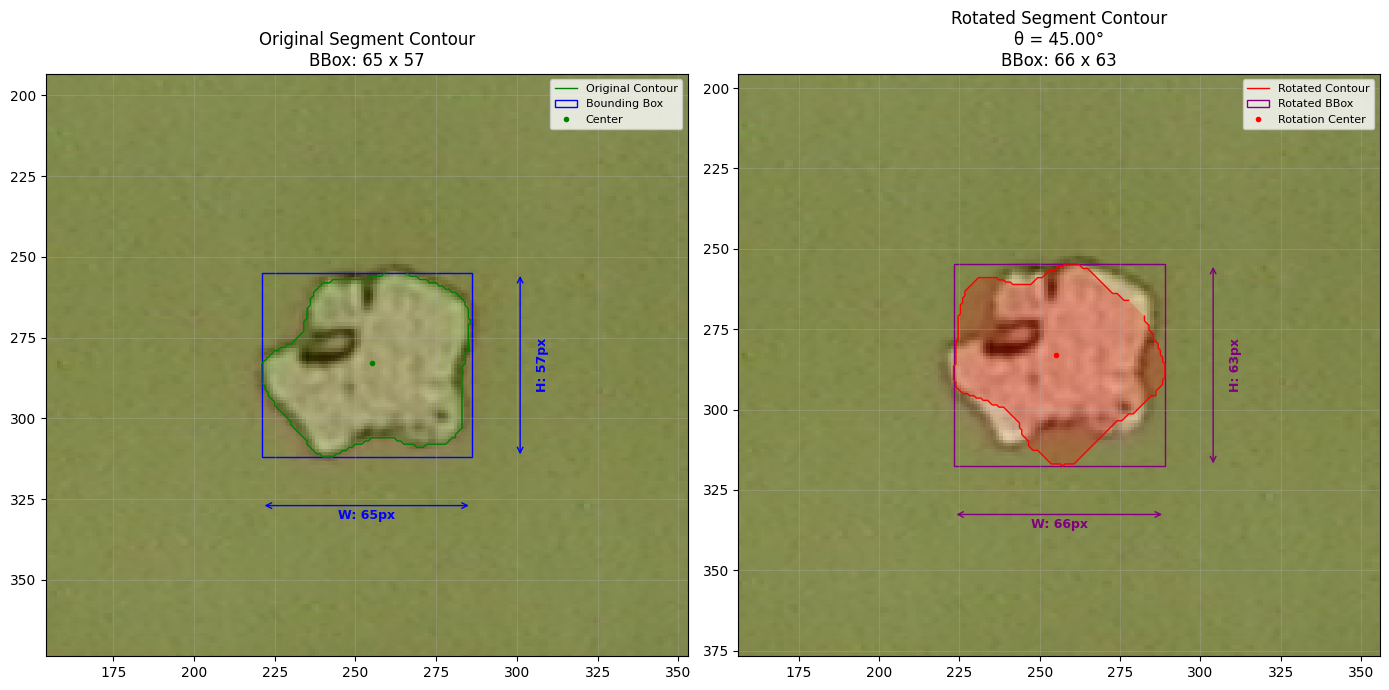


🎯 SEGMENT CONTOUR ANALYSIS:
   📐 Rotation Angle: 45.00°
   📍 Rotation Center: (255.0, 283.0)

📏 ORIGINAL CONTOUR BOUNDING BOX:
   x_min: 221.0
   x_max: 286.0
   y_min: 255.0
   y_max: 312.0
   Width: 65.0 px
   Height: 57.0 px

📏 ROTATED CONTOUR BOUNDING BOX:
   x_min: 223.2
   x_max: 288.9
   y_min: 254.7
   y_max: 317.6
   Width: 65.8 px
   Height: 62.9 px

📊 BOUNDING BOX COMPARISON:
   Width Change: 0.8 px
   Height Change: 5.9 px

💾 Visualization: segment_thin_with_axes_20250618_163100.png


In [11]:
#!/usr/bin/env python3
"""
Rotate Segmented Contour with Thin Lines and Axes
"""

import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple

def load_segmentation_json(json_file: str) -> dict:
    """Load segmentation JSON data"""
    with open(json_file, 'r') as f:
        return json.load(f)

def rotate_contour(points: List[List[int]], center: Tuple[float, float], theta: float) -> np.ndarray:
    """Rotate entire contour around center by theta degrees"""
    
    # Convert to numpy array
    points_array = np.array(points, dtype=float)
    
    # Convert angle to radians
    angle_rad = np.radians(theta)
    cos_theta = np.cos(angle_rad)
    sin_theta = np.sin(angle_rad)
    
    # Translate to origin (center)
    translated_points = points_array - np.array(center)
    
    # Apply rotation matrix
    rotation_matrix = np.array([
        [cos_theta, -sin_theta],
        [sin_theta, cos_theta]
    ])
    
    rotated_points = translated_points @ rotation_matrix.T
    
    # Translate back
    final_points = rotated_points + np.array(center)
    
    return final_points

def get_bounding_box_coordinates(points: np.ndarray) -> dict:
    """Get bounding box coordinates from points"""
    
    x_min = np.min(points[:, 0])
    x_max = np.max(points[:, 0])
    y_min = np.min(points[:, 1])
    y_max = np.max(points[:, 1])
    
    width = x_max - x_min
    height = y_max - y_min
    
    return {
        "x_min": float(x_min),
        "x_max": float(x_max),
        "y_min": float(y_min),
        "y_max": float(y_max),
        "width": float(width),
        "height": float(height)
    }

def draw_measurement_axes(ax, bbox: dict, color: str = 'black'):
    """Draw measurement axes for width and height"""
    
    x_min, x_max = bbox["x_min"], bbox["x_max"]
    y_min, y_max = bbox["y_min"], bbox["y_max"]
    width, height = bbox["width"], bbox["height"]
    
    # Width axis (horizontal)
    y_axis_pos = y_max + 15  # Below the bbox
    ax.annotate('', xy=(x_max, y_axis_pos), xytext=(x_min, y_axis_pos),
                arrowprops=dict(arrowstyle='<->', color=color, lw=1))
    ax.text((x_min + x_max) / 2, y_axis_pos + 5, f'W: {width:.0f}px', 
            ha='center', va='bottom', fontsize=9, color=color, weight='bold')
    
    # Height axis (vertical)
    x_axis_pos = x_max + 15  # Right of the bbox
    ax.annotate('', xy=(x_axis_pos, y_max), xytext=(x_axis_pos, y_min),
                arrowprops=dict(arrowstyle='<->', color=color, lw=1))
    ax.text(x_axis_pos + 5, (y_min + y_max) / 2, f'H: {height:.0f}px', 
            ha='left', va='center', fontsize=9, color=color, weight='bold', rotation=90)

def visualize_contours_with_bbox(image_path: str, seg_data: dict):
    """Visualize original and rotated contours with thin bounding boxes and axes"""
    
    # Load image
    image = cv2.imread(image_path)
    if image is None:
        print(f"❌ Cannot load image: {image_path}")
        return
    
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Get data
    theta = seg_data["theta"]
    contour = seg_data["contours"][0]
    points = contour["points"]
    original_center = [contour["center"]["x"], contour["center"]["y"]]
    
    # Convert original points to numpy array
    original_points = np.array(points)
    
    # Get original bounding box
    original_bbox = get_bounding_box_coordinates(original_points)
    
    # Rotate the entire contour
    rotated_contour = rotate_contour(points, original_center, theta)
    
    # Get rotated contour bounding box
    rotated_bbox = get_bounding_box_coordinates(rotated_contour)
    
    # Create visualization with more space for axes
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    
    # 1. Original segmented contour with bounding box
    axes[0].imshow(image_rgb)
    
    # Draw original contour (thin line)
    axes[0].plot(original_points[:, 0], original_points[:, 1], 'g-', linewidth=1, label='Original Contour')
    axes[0].fill(original_points[:, 0], original_points[:, 1], 'green', alpha=0.2)
    
    # Draw original bounding box (thin)
    orig_rect = plt.Rectangle((original_bbox["x_min"], original_bbox["y_min"]), 
                             original_bbox["width"], original_bbox["height"],
                             fill=False, color='blue', linewidth=1, label='Bounding Box')
    axes[0].add_patch(orig_rect)
    
    # Draw measurement axes
    draw_measurement_axes(axes[0], original_bbox, 'blue')
    
    # Small center dot
    axes[0].plot(original_center[0], original_center[1], 'go', markersize=3, label='Center')
    
    axes[0].set_title(f"Original Segment Contour\nBBox: {original_bbox['width']:.0f} x {original_bbox['height']:.0f}")
    axes[0].legend(fontsize=8)
    axes[0].axis('equal')
    axes[0].grid(True, alpha=0.3)
    
    # Add some padding for axes
    x_pad = max(50, original_bbox["width"] * 0.1)
    y_pad = max(50, original_bbox["height"] * 0.1)
    axes[0].set_xlim(original_bbox["x_min"] - x_pad, original_bbox["x_max"] + x_pad)
    axes[0].set_ylim(original_bbox["y_max"] + y_pad, original_bbox["y_min"] - y_pad)  # Inverted for image coords
    
    # 2. Rotated contour with bounding box
    axes[1].imshow(image_rgb)
    
    # Draw rotated contour (thin line)
    axes[1].plot(rotated_contour[:, 0], rotated_contour[:, 1], 'r-', linewidth=1, label=f'Rotated Contour')
    axes[1].fill(rotated_contour[:, 0], rotated_contour[:, 1], 'red', alpha=0.2)
    
    # Draw rotated contour bounding box (thin)
    rot_rect = plt.Rectangle((rotated_bbox["x_min"], rotated_bbox["y_min"]), 
                            rotated_bbox["width"], rotated_bbox["height"],
                            fill=False, color='purple', linewidth=1, label='Rotated BBox')
    axes[1].add_patch(rot_rect)
    
    # Draw measurement axes
    draw_measurement_axes(axes[1], rotated_bbox, 'purple')
    
    # Small center dot
    axes[1].plot(original_center[0], original_center[1], 'ro', markersize=3, label='Rotation Center')
    
    axes[1].set_title(f"Rotated Segment Contour\nθ = {theta:.2f}°\nBBox: {rotated_bbox['width']:.0f} x {rotated_bbox['height']:.0f}")
    axes[1].legend(fontsize=8)
    axes[1].axis('equal')
    axes[1].grid(True, alpha=0.3)
    
    # Add some padding for axes
    x_pad = max(50, rotated_bbox["width"] * 0.1)
    y_pad = max(50, rotated_bbox["height"] * 0.1)
    axes[1].set_xlim(rotated_bbox["x_min"] - x_pad, rotated_bbox["x_max"] + x_pad)
    axes[1].set_ylim(rotated_bbox["y_max"] + y_pad, rotated_bbox["y_min"] - y_pad)  # Inverted for image coords
    
    plt.tight_layout()
    
    # Save result
    output_file = f"segment_thin_with_axes_{seg_data['timestamp']}.png"
    plt.savefig(output_file, dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print detailed coordinates
    print(f"\n🎯 SEGMENT CONTOUR ANALYSIS:")
    print(f"   📐 Rotation Angle: {theta:.2f}°")
    print(f"   📍 Rotation Center: ({original_center[0]:.1f}, {original_center[1]:.1f})")
    
    print(f"\n📏 ORIGINAL CONTOUR BOUNDING BOX:")
    print(f"   x_min: {original_bbox['x_min']:.1f}")
    print(f"   x_max: {original_bbox['x_max']:.1f}")
    print(f"   y_min: {original_bbox['y_min']:.1f}")
    print(f"   y_max: {original_bbox['y_max']:.1f}")
    print(f"   Width: {original_bbox['width']:.1f} px")
    print(f"   Height: {original_bbox['height']:.1f} px")
    
    print(f"\n📏 ROTATED CONTOUR BOUNDING BOX:")
    print(f"   x_min: {rotated_bbox['x_min']:.1f}")
    print(f"   x_max: {rotated_bbox['x_max']:.1f}")
    print(f"   y_min: {rotated_bbox['y_min']:.1f}")
    print(f"   y_max: {rotated_bbox['y_max']:.1f}")
    print(f"   Width: {rotated_bbox['width']:.1f} px")
    print(f"   Height: {rotated_bbox['height']:.1f} px")
    
    print(f"\n📊 BOUNDING BOX COMPARISON:")
    print(f"   Width Change: {rotated_bbox['width'] - original_bbox['width']:.1f} px")
    print(f"   Height Change: {rotated_bbox['height'] - original_bbox['height']:.1f} px")
    
    print(f"\n💾 Visualization: {output_file}")
    
    return {
        "original_contour": points,
        "rotated_contour": rotated_contour.tolist(),
        "original_bbox": original_bbox,
        "rotated_bbox": rotated_bbox,
        "rotation_center": original_center,
        "theta": theta
    }

def main():
    """Main function"""
    
    # Load JSON data
    json_file = "sam_segmentation_results/segmentation_data_ThuaDong_20250618_163100.json"
    image_path = "/home/jkl0909/TestCycletimeMeiko/PCB_Project/data/raw/thuadong/testthuadong.jpg"
    
    try:
        seg_data = load_segmentation_json(json_file)
        print(f"📂 Loaded: {json_file}")
        print(f"🎯 Class: {seg_data['class_name']}")
        print(f"🔄 Theta: {seg_data['theta']:.2f}°")
        
        # Visualize contours with thin lines and axes
        visualize_contours_with_bbox(image_path, seg_data)
        
    except Exception as e:
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()